<div style="background:linear-gradient(135deg,#1a1a2e,#16213e,#0f3460);padding:32px 28px;border-radius:12px;margin-bottom:8px">
<h1 style="color:#e9c46a;margin:0 0 6px">🏆 FIFA World Cup 2026</h1>
<h2 style="color:#a8dadc;font-weight:400;margin:0 0 14px">Notebook 4 of 4 — WC 2026 Prediction & Simulation</h2>
<p style="color:#ccc;line-height:1.6;margin:0 0 16px">
The payoff notebook. We load our trained model and apply it to all 72 WC 2026 group
fixtures, compute probabilistic group standings, then simulate the full knockout bracket
from Round of 32 all the way to the Final.
</p>
<span style="padding:4px 12px;border-radius:20px;font-size:.85em;color:white;background:#2a9d8f">🏆 Prediction</span>
<span style="padding:4px 12px;border-radius:20px;font-size:.85em;color:white;background:#e9c46a;color:#333;margin-left:6px">72 Group Matches</span>
<span style="padding:4px 12px;border-radius:20px;font-size:.85em;color:white;background:#e76f51;margin-left:6px">Full Knockout</span>
<span style="padding:4px 12px;border-radius:20px;font-size:.85em;color:white;background:#6a4c93;margin-left:6px">💾 Saves CSVs</span>
</div>

---
> **Prerequisite:** Run `02_feature_engineering.ipynb` and `03_modeling.ipynb` first.
> All required files are loaded from the `features/` folder.


## 1. Imports

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import pickle, json, warnings
from collections import defaultdict, deque
warnings.filterwarnings("ignore")

PALETTE = ["#2a9d8f","#e9c46a","#e76f51","#264653","#a8dadc",
           "#457b9d","#fca311","#6a4c93","#f4a261","#1d3557"]
print("✅ Imports ready")

✅ Imports ready


## 2. Load Model, ELO, H2H & Fixtures

In [15]:
# Best model
with open("features/best_model.pkl","rb") as f:
    bundle = pickle.load(f)
best_model = bundle["model"]
best_name  = bundle["name"]
classes    = bundle["classes"]
scaler     = bundle["scaler"]
FEATURES   = bundle["features"]
print(f"✅ Model loaded: {best_name}")

# ELO ratings
with open("features/elo_final.json") as f:
    elo_raw = json.load(f)
elo = defaultdict(lambda: 1500.0, {k: float(v) for k,v in elo_raw.items()})
print(f"✅ ELO loaded: {len(elo)} teams")

# H2H records
with open("features/h2h.json") as f:
    h2h_raw = json.load(f)
h2h = defaultdict(lambda: {"w":0,"d":0,"l":0})
for k, v in h2h_raw.items():
    key = eval(k)
    h2h[key] = v
print(f"✅ H2H loaded: {len(h2h)} records")

# WC 2026 group fixtures
wc26_fix = pd.read_csv("features/wc26_fixtures.csv")
wc26_fix["date"] = pd.to_datetime(wc26_fix["date"])
print(f"✅ Fixtures loaded: {len(wc26_fix)} matches")

# team_form: re-build from feature CSV (needed for gf/ga averages)
feat_df = pd.read_csv("features/historical_features.csv")
feat_df["date"] = pd.to_datetime(feat_df["date"])
print(f"✅ Feature matrix loaded: {len(feat_df):,} rows")

✅ Model loaded: Gradient Boosting
✅ ELO loaded: 333 teams
✅ H2H loaded: 14924 records
✅ Fixtures loaded: 72 matches
✅ Feature matrix loaded: 49,215 rows


## 3. Rebuild Team Form Snapshot

In [16]:
# We rebuild team_form so predict_match can get live gf/ga averages
FORM_W    = 10
team_form = defaultdict(lambda: deque(maxlen=FORM_W))

for _, m in feat_df.sort_values("date").iterrows():
    if pd.isna(m.get("home_score")) or pd.isna(m.get("away_score")): continue
    home, away = m["home_team"], m["away_team"]
    hg, ag     = m["home_score"], m["away_score"]
    is_comp    = "friendly" not in str(m.get("tournament","")).lower()
    team_form[home].append((hg, ag, is_comp))
    team_form[away].append((ag, hg, is_comp))
print(f"✅ Form rebuilt for {len(team_form)} teams")

✅ Form rebuilt for 333 teams


## 4. Prediction Helper Functions

In [17]:
def team_feats(team):
    """Current ELO + form snapshot for a team."""
    e  = elo[team]
    fm = team_form[team]
    if len(fm) >= 3:
        wr = sum(1 for g,a,_ in fm if g>a)/len(fm)
        gf = sum(g for g,_,_ in fm)/len(fm)
        ga = sum(a for _,a,_ in fm)/len(fm)
        cw = sum(1 for g,a,c in fm if g>a and c)/len(fm)
    else:
        wr, gf, ga, cw = 0.4, 1.2, 1.2, 0.4
    return {"elo":e, "wr":wr, "gf":gf, "ga":ga, "cw":cw}

def predict_match(ta, tb, neutral=True, is_wc_game=True):
    """Return {Home Win, Draw, Away Win} probability dict."""
    a = team_feats(ta); b = team_feats(tb)
    rh=h2h[(ta,tb)]; ra=h2h[(tb,ta)]
    th=rh["w"]+rh["d"]+rh["l"]; ta2=ra["w"]+ra["d"]+ra["l"]
    row = np.array([[
        a["elo"],b["elo"],a["elo"]-b["elo"],
        a["wr"], b["wr"], a["wr"]-b["wr"],
        a["gf"], a["ga"], b["gf"], b["ga"],
        a["cw"], b["cw"],
        rh["w"]/th if th>0 else 0.4,
        ra["w"]/ta2 if ta2>0 else 0.4,
        int(neutral), int(is_wc_game),
    ]])
    if best_name == "Logistic Regression":
        row = scaler.transform(row)
    probs = best_model.predict_proba(row)[0]
    return dict(zip(classes, probs))

# Sanity checks
for ta, tb in [("Brazil","Argentina"),("France","Morocco"),("England","Germany")]:
    p = predict_match(ta, tb)
    print(f"{ta:>12s} vs {tb:<12s} → {ta} win {p.get('Home Win',0):.1%} | "
          f"Draw {p['Draw']:.1%} | {tb} win {p.get('Away Win',0):.1%}")

      Brazil vs Argentina    → Brazil win 16.6% | Draw 12.8% | Argentina win 70.6%
      France vs Morocco      → France win 64.3% | Draw 24.5% | Morocco win 11.3%
     England vs Germany      → England win 39.6% | Draw 26.3% | Germany win 34.0%


## 5. Group Stage Predictions

In [18]:
match_preds = []
for _, fx in wc26_fix.iterrows():
    ta, tb = fx["home_team"], fx["away_team"]
    p  = predict_match(ta, tb)
    af = team_feats(ta); bf = team_feats(tb)
    eg_a = (af["gf"] + bf["ga"]) / 2
    eg_b = (bf["gf"] + af["ga"]) / 2
    match_preds.append({
        "date":fx["date"], "team_a":ta, "team_b":tb,
        "p_home":round(p.get("Home Win",0),3),
        "p_draw":round(p.get("Draw",0),3),
        "p_away":round(p.get("Away Win",0),3),
        "predicted":max(p,key=p.get),
        "exp_gf_a":round(eg_a,2), "exp_gf_b":round(eg_b,2),
        "elo_a":round(elo[ta]), "elo_b":round(elo[tb]),
    })

preds_df = pd.DataFrame(match_preds)
print(f"Predicted {len(preds_df)} group-stage fixtures")
preds_df.head(10)

Predicted 72 group-stage fixtures


,date,team_a,team_b,p_home,p_draw,p_away,predicted,exp_gf_a,exp_gf_b,elo_a,elo_b
0,2026-06-11,Mexico,South Africa,0.671,0.242,0.087,Home Win,1.10,1.25,1889,1658
1,2026-06-11,South Korea,Czech Republic,0.539,0.283,0.179,Home Win,1.35,1.50,1828,1722
2,2026-06-12,Canada,Bosnia and Herzegovina,0.723,0.202,0.076,Home Win,1.10,1.25,1820,1582
3,2026-06-12,United States,Paraguay,0.491,0.273,0.236,Home Win,1.35,1.30,1824,1766
4,2026-06-13,Australia,Turkey,0.406,0.221,0.373,Home Win,1.45,1.50,1847,1821
5,2026-06-13,Haiti,Scotland,0.301,0.272,0.427,Away Win,1.20,1.45,1687,1749
6,2026-06-13,Brazil,Morocco,0.482,0.241,0.277,Home Win,1.15,1.30,1958,1898
7,2026-06-13,Qatar,Switzerland,0.193,0.244,0.563,Away Win,0.85,2.20,1643,1814
8,2026-06-14,Germany,Curaçao,0.798,0.157,0.044,Home Win,1.80,1.35,1919,1596
9,2026-06-14,Ivory Coast,Ecuador,0.293,0.253,0.454,Away Win,1.20,0.70,1747,1865


## 6. Probabilistic Group Standings

In [19]:
# Auto-detect groups from fixture pairings
team_opps = defaultdict(set)
for m in match_preds:
    team_opps[m["team_a"]].add(m["team_b"])
    team_opps[m["team_b"]].add(m["team_a"])
all_wc_teams = {t for m in match_preds for t in [m["team_a"],m["team_b"]]}

visited, groups_list = set(), []
for t in sorted(all_wc_teams):
    if t in visited: continue
    grp, queue = {t}, [t]
    while queue:
        curr = queue.pop()
        for opp in team_opps[curr]:
            if opp not in grp and len(grp) < 4:
                grp.add(opp); queue.append(opp)
    for x in grp: visited.add(x)
    groups_list.append(sorted(grp))

all_stands = []
for i, group in enumerate(groups_list):
    lbl = chr(65+i)
    pts_m, gd_m = {}, {}
    for ta in group:
        pts=0; gd=0
        for m in match_preds:
            if m["team_a"]==ta:
                pts += m["p_home"]*3 + m["p_draw"]
                gd  += m["p_home"]*(m["exp_gf_a"]-m["exp_gf_b"])
            elif m["team_b"]==ta:
                pts += m["p_away"]*3 + m["p_draw"]
                gd  += m["p_away"]*(m["exp_gf_b"]-m["exp_gf_a"])
        pts_m[ta]=pts; gd_m[ta]=gd
    ranked = sorted(group, key=lambda t:(pts_m[t],gd_m[t],elo[t]), reverse=True)
    for pos,t in enumerate(ranked,1):
        all_stands.append({"group":lbl,"pos":pos,"team":t,
                           "pts":round(pts_m[t],2),"gd":round(gd_m[t],2),"elo":round(elo[t])})

stands_df = pd.DataFrame(all_stands)
print("Group standings — top 2 qualifiers per group:")
print(stands_df[stands_df["pos"]<=2].to_string(index=False))

Group standings — top 2 qualifiers per group:
group  pos          team  pts    gd  elo
    A    1     Argentina 6.57  0.73 2036
    A    2       Austria 3.96  0.58 1787
    B    1 United States 4.50 -0.18 1824
    B    2     Australia 4.47  0.20 1847
    C    1          Iran 5.60  0.15 1853
    C    2       Belgium 4.66  1.54 1863
    D    1        Canada 6.16  0.29 1820
    D    2   Switzerland 5.49  1.16 1814
    E    1        Brazil 6.48  0.42 1958
    E    2       Morocco 5.41  0.67 1898
    F    1         Spain 5.75  1.71 2063
    F    2       Uruguay 5.51 -0.36 1876
    G    1      Portugal 5.69  0.55 1969
    G    2      Colombia 5.08  0.07 1920
    H    1       England 6.28  0.82 1960
    H    2       Croatia 4.83  1.05 1891
    I    1       Germany 6.23  0.50 1919
    I    2       Ecuador 5.18 -0.35 1865
    J    1        Mexico 6.17 -0.31 1889
    J    2   South Korea 4.85 -0.09 1828
    K    1        France 6.38  0.03 2024
    K    2       Senegal 4.29  0.41 1840
    L    1 

## 7. Group Standings Visualization

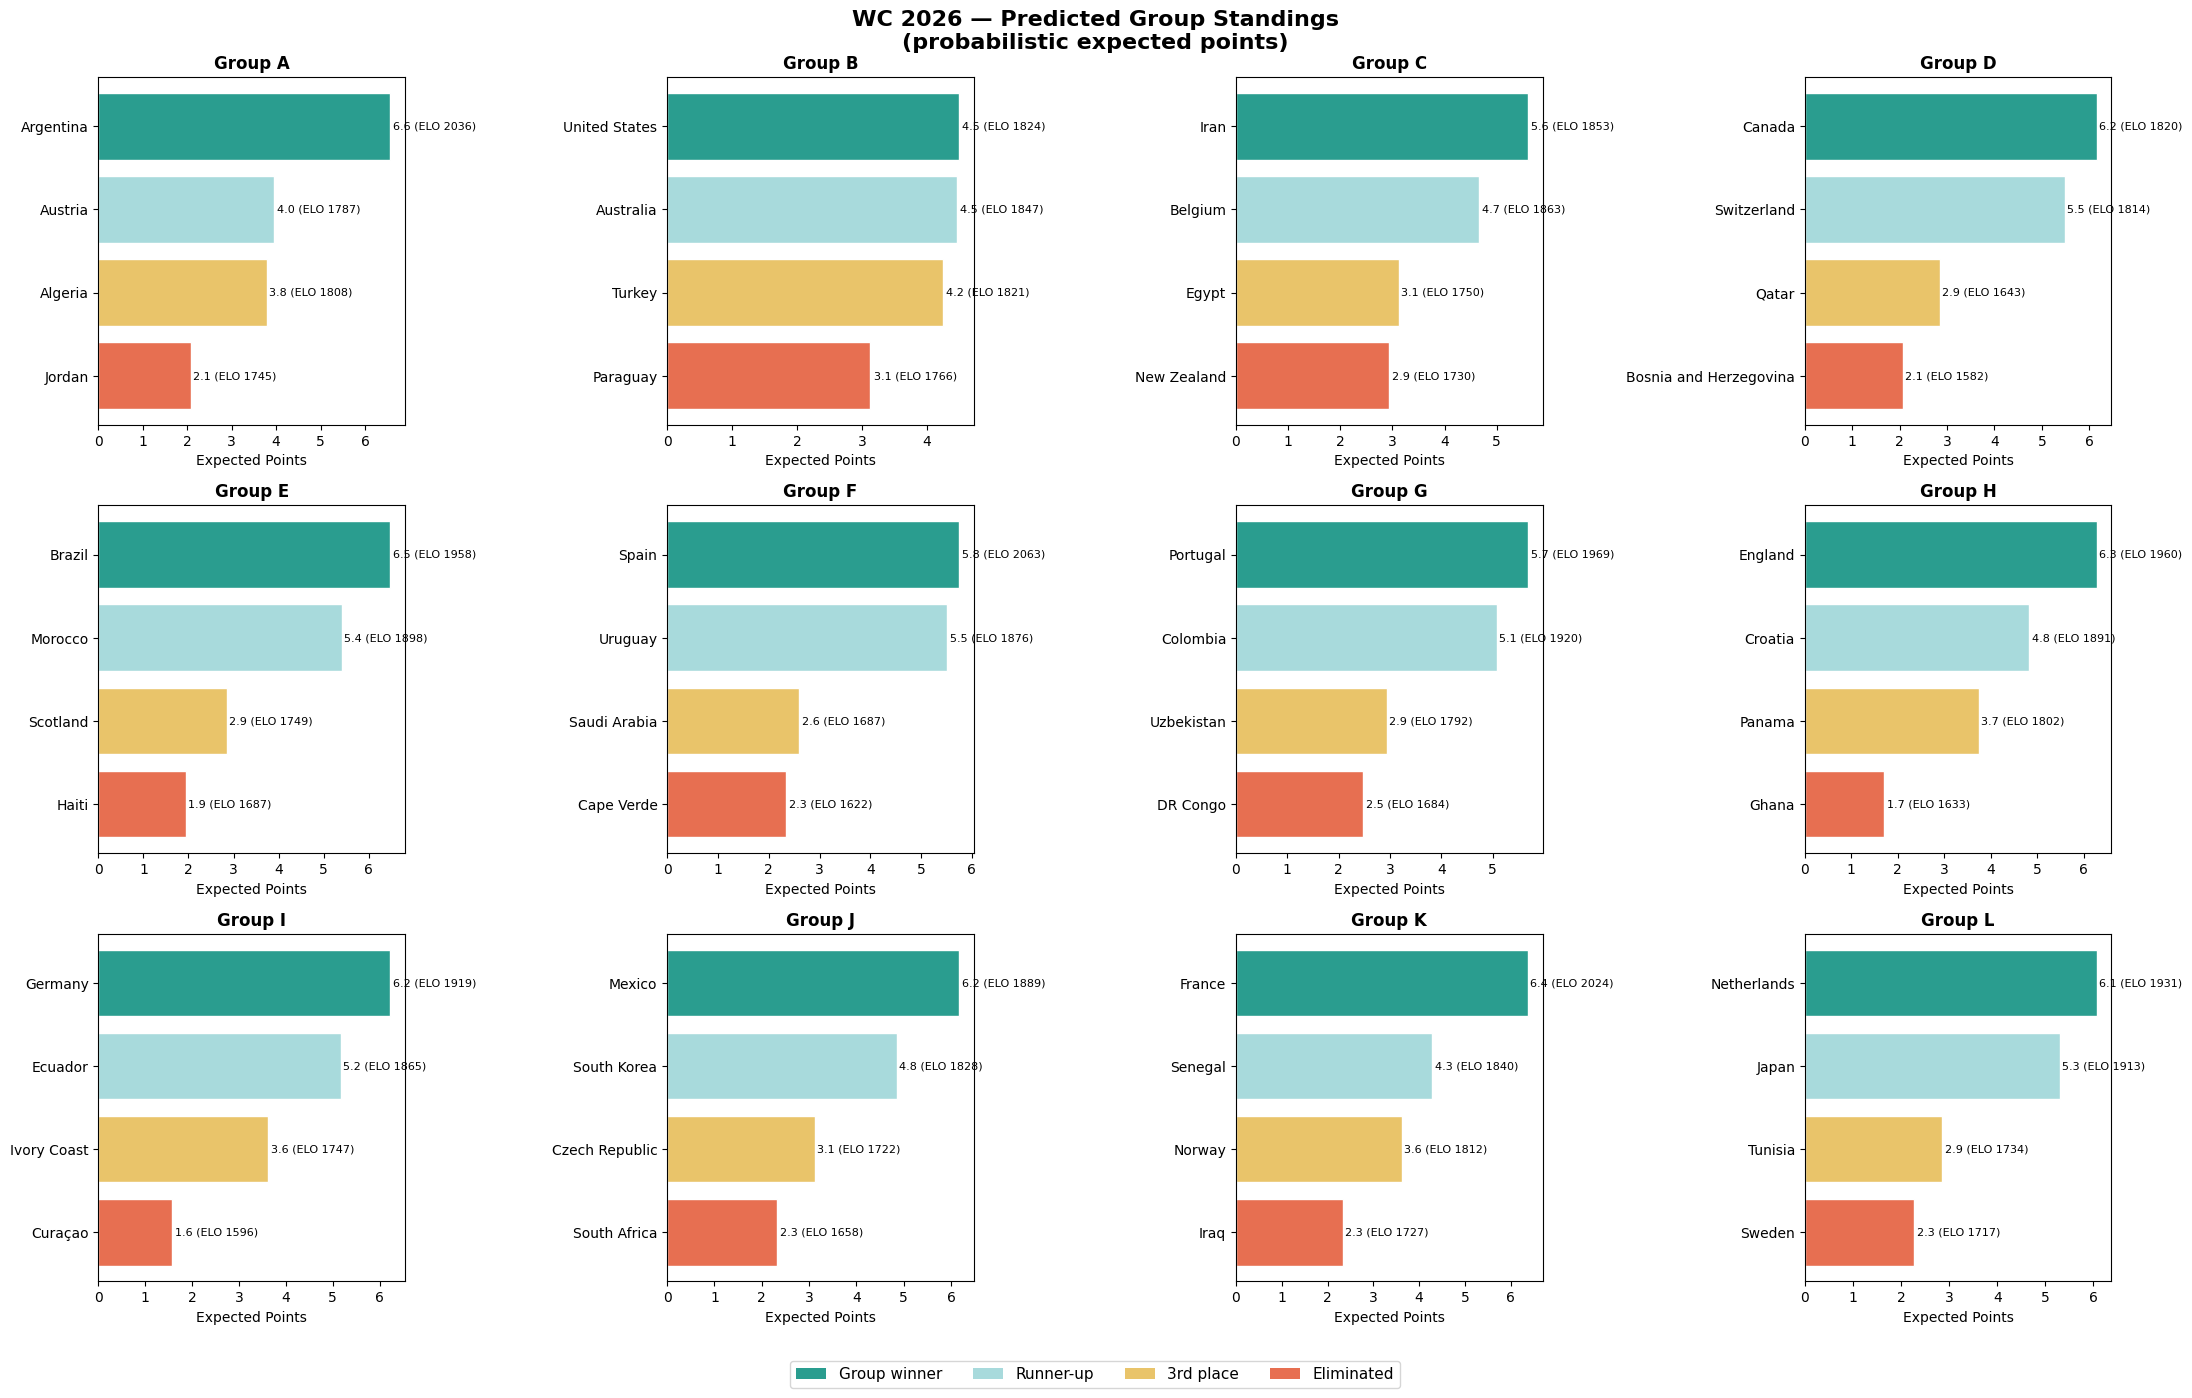

In [20]:
pos_color = {1:"#2a9d8f",2:"#a8dadc",3:"#e9c46a",4:"#e76f51"}
fig, axes = plt.subplots(3, 4, figsize=(22, 14))
axes = axes.flatten()

for i, group in enumerate(sorted(set(stands_df["group"]))):
    grp  = stands_df[stands_df["group"]==group].sort_values("pos")
    bars = axes[i].barh(grp["team"], grp["pts"],
                        color=[pos_color[p] for p in grp["pos"]], edgecolor="white")
    axes[i].set_title(f"Group {group}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Expected Points"); axes[i].invert_yaxis()
    for bar, row in zip(bars, grp.itertuples()):
        axes[i].text(row.pts+0.05, bar.get_y()+bar.get_height()/2,
                     f"{row.pts:.1f} (ELO {row.elo})", va="center", fontsize=8)

legend_elements = [Patch(facecolor=c, label=l) for c,l in
                   [("#2a9d8f","Group winner"),("#a8dadc","Runner-up"),
                    ("#e9c46a","3rd place"),("#e76f51","Eliminated")]]
fig.legend(handles=legend_elements, loc="lower center", ncol=4,
           fontsize=11, bbox_to_anchor=(0.5,-0.01))
plt.suptitle("WC 2026 — Predicted Group Standings\n(probabilistic expected points)",
             fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0,0.03,1,1]); plt.show()

## 8. Knockout Bracket Simulation

In [21]:
qualifiers = stands_df[stands_df["pos"]<=2].copy()
best3rd    = stands_df[stands_df["pos"]==3].sort_values(["pts","gd","elo"],ascending=False).head(8)
bracket_df = pd.concat([qualifiers,best3rd]).sort_values(
                 ["pts","gd","elo"],ascending=False).reset_index(drop=True)
bracket_df["seed"] = range(1, len(bracket_df)+1)
print(f"32 qualifiers seeded:")
print(bracket_df[["seed","group","team","pos","pts","elo"]].to_string(index=False))

32 qualifiers seeded:
 seed group           team  pos  pts  elo
    1     A      Argentina    1 6.57 2036
    2     E         Brazil    1 6.48 1958
    3     K         France    1 6.38 2024
    4     H        England    1 6.28 1960
    5     I        Germany    1 6.23 1919
    6     J         Mexico    1 6.17 1889
    7     D         Canada    1 6.16 1820
    8     L    Netherlands    1 6.07 1931
    9     F          Spain    1 5.75 2063
   10     G       Portugal    1 5.69 1969
   11     C           Iran    1 5.60 1853
   12     F        Uruguay    2 5.51 1876
   13     D    Switzerland    2 5.49 1814
   14     E        Morocco    2 5.41 1898
   15     L          Japan    2 5.30 1913
   16     I        Ecuador    2 5.18 1865
   17     G       Colombia    2 5.08 1920
   18     J    South Korea    2 4.85 1828
   19     H        Croatia    2 4.83 1891
   20     C        Belgium    2 4.66 1863
   21     B  United States    1 4.50 1824
   22     B      Australia    2 4.47 1847
   23     K 

In [22]:
def ko_match(ta, tb):
    p    = predict_match(ta, tb)
    best = max(p, key=p.get)
    if best == "Home Win": return ta, p
    if best == "Away Win": return tb, p
    return (ta,p) if elo[ta] >= elo[tb] else (tb,p)

def sim_round(teams, name):
    print(f"\n  {'─'*56}")
    print(f"  {name}")
    print(f"  {'─'*56}")
    winners = []
    pairs   = list(zip(teams[:len(teams)//2], reversed(teams[len(teams)//2:])))
    for ta,tb in pairs:
        w,p = ko_match(ta,tb)
        hw=p.get("Home Win",0); dr=p.get("Draw",0); aw=p.get("Away Win",0)
        mk = "🏆" if name=="FINAL" else "✅"
        print(f"  {ta:>22s}  vs  {tb:<22s}  →  {mk} {w}  ({hw:.0%}/{dr:.0%}/{aw:.0%})")
        winners.append(w)
    return winners

bracket = list(bracket_df["team"])
r32  = sim_round(bracket, "Round of 32")
r16  = sim_round(r32,     "Round of 16")
qf   = sim_round(r16,     "Quarter-finals")
sf   = sim_round(qf,      "Semi-finals")
fin  = sim_round(sf,      "FINAL")
champ = fin[0]

print(f"\n{'='*60}")
print(f"  🏆  PREDICTED WC 2026 CHAMPION: {champ.upper()}")
print(f"{'='*60}")


  ────────────────────────────────────────────────────────
  Round of 32
  ────────────────────────────────────────────────────────
               Argentina  vs  Uzbekistan              →  ✅ Argentina  (70%/20%/10%)
                  Brazil  vs  Egypt                   →  ✅ Brazil  (72%/18%/10%)
                  France  vs  Czech Republic          →  ✅ France  (71%/20%/9%)
                 England  vs  Norway                  →  ✅ England  (62%/24%/14%)
                 Germany  vs  Ivory Coast             →  ✅ Germany  (68%/15%/16%)
                  Mexico  vs  Panama                  →  ✅ Mexico  (50%/31%/19%)
                  Canada  vs  Algeria                 →  ✅ Canada  (40%/25%/35%)
             Netherlands  vs  Austria                 →  ✅ Netherlands  (55%/33%/12%)
                   Spain  vs  Turkey                  →  ✅ Spain  (25%/70%/5%)
                Portugal  vs  Senegal                 →  ✅ Portugal  (64%/18%/18%)
                    Iran  vs  Australia         

## 9. Bracket Path Visualization

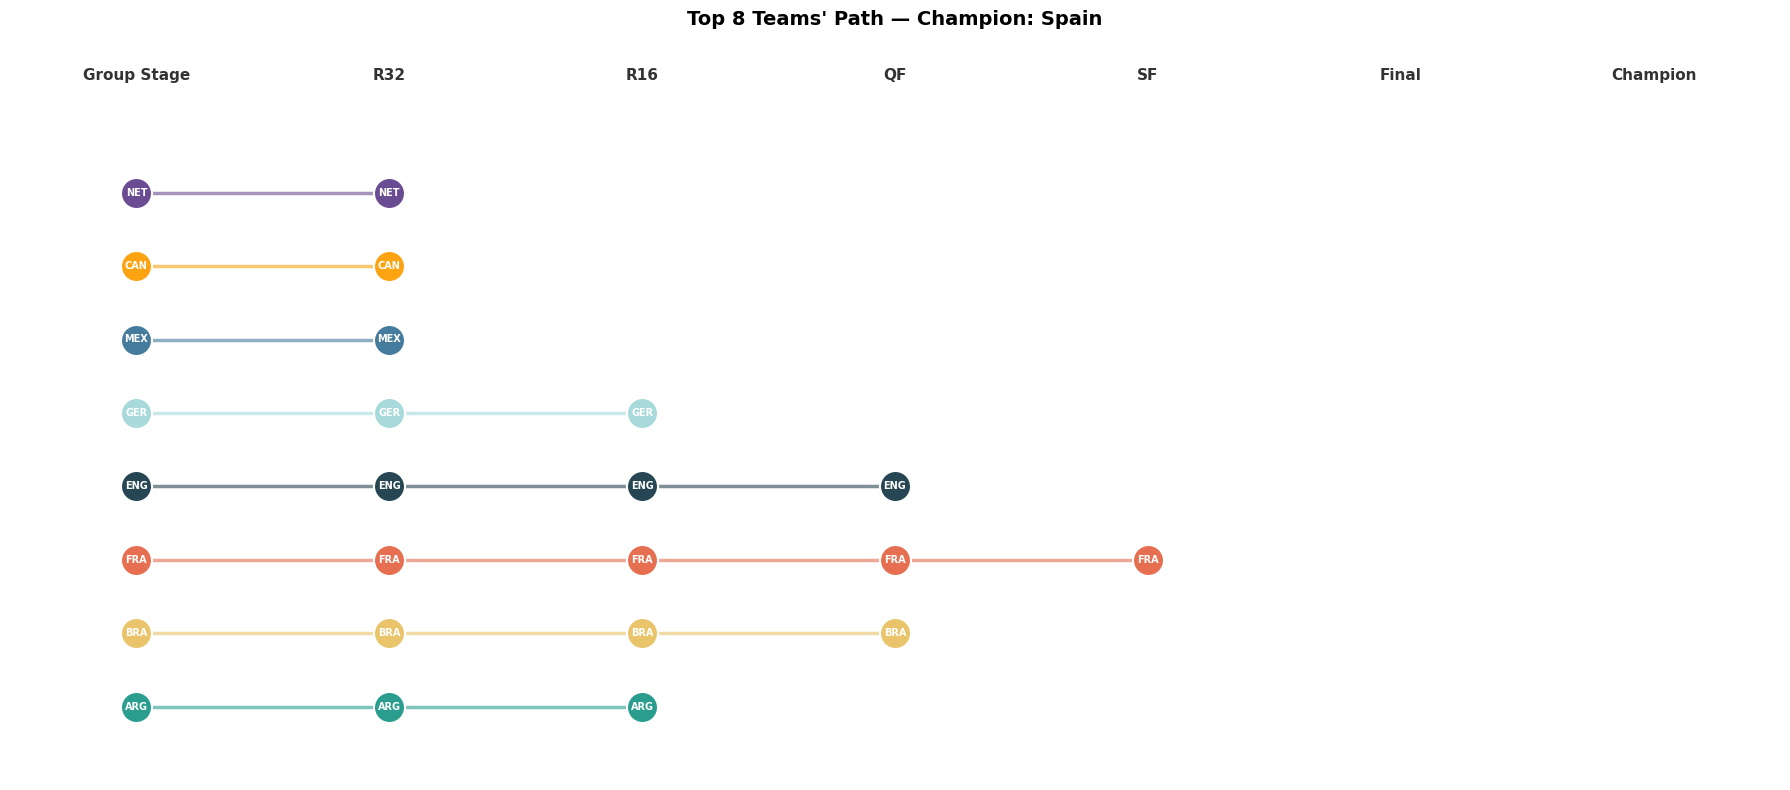

In [23]:
all_rounds = [bracket,r32,r16,qf,sf,fin,[champ]]
rnd_names  = ["Group Stage","R32","R16","QF","SF","Final","Champion"]
top8       = bracket_df.head(8)["team"].tolist()
colors_path = {t:PALETTE[i%len(PALETTE)] for i,t in enumerate(top8)}

fig, ax = plt.subplots(figsize=(18, 8))
ax.set_xlim(-0.5, len(rnd_names)-0.5)
ax.set_ylim(-1, len(top8)+1)
ax.axis("off")

for xi,(rnd,rname) in enumerate(zip(all_rounds,rnd_names)):
    ax.text(xi,len(top8)+0.5,rname,ha="center",va="bottom",fontsize=11,fontweight="bold",color="#333")
    for t in [t for t in top8 if t in rnd]:
        col = colors_path.get(t,"#888")
        yi  = top8.index(t)
        ax.scatter(xi,yi,s=500,color=col,zorder=5,edgecolors="white",linewidths=1.5)
        ax.text(xi,yi,t[:3].upper(),ha="center",va="center",fontsize=7,fontweight="bold",color="white",zorder=6)
        if xi < len(all_rounds)-1 and t in all_rounds[xi+1]:
            ax.plot([xi,xi+1],[yi,yi],color=col,linewidth=2.5,alpha=0.6,zorder=4)

ax.set_title(f"Top 8 Teams' Path — Champion: {champ}",fontsize=14,fontweight="bold",pad=15)
plt.tight_layout(); plt.show()

## 10. Final Summary

In [24]:
print("="*65)
print("  FIFA WORLD CUP 2026 — FINAL PREDICTION SUMMARY")
print("="*65)

print("\n🏅 PREDICTED GROUP WINNERS")
for grp in sorted(set(stands_df["group"])):
    w   = stands_df[(stands_df["group"]==grp)&(stands_df["pos"]==1)]["team"].values[0]
    pts = stands_df[(stands_df["group"]==grp)&(stands_df["pos"]==1)]["pts"].values[0]
    print(f"   Group {grp}: {w:<22s} ({pts:.1f} exp pts)")

print(f"\n📌 SEMI-FINALISTS: {', '.join(sf)}")
print(f"\n🏆 CHAMPION       : {champ.upper()}")

  FIFA WORLD CUP 2026 — FINAL PREDICTION SUMMARY

🏅 PREDICTED GROUP WINNERS
   Group A: Argentina              (6.6 exp pts)
   Group B: United States          (4.5 exp pts)
   Group C: Iran                   (5.6 exp pts)
   Group D: Canada                 (6.2 exp pts)
   Group E: Brazil                 (6.5 exp pts)
   Group F: Spain                  (5.8 exp pts)
   Group G: Portugal               (5.7 exp pts)
   Group H: England                (6.3 exp pts)
   Group I: Germany                (6.2 exp pts)
   Group J: Mexico                 (6.2 exp pts)
   Group K: France                 (6.4 exp pts)
   Group L: Netherlands            (6.1 exp pts)

📌 SEMI-FINALISTS: Spain, France

🏆 CHAMPION       : SPAIN


## 11. Save Outputs

In [25]:
import os
os.makedirs("outputs", exist_ok=True)

preds_df.to_csv("outputs/wc2026_match_predictions.csv", index=False)
stands_df.to_csv("outputs/wc2026_standings.csv", index=False)
print("✅ outputs/wc2026_match_predictions.csv")
print("✅ outputs/wc2026_standings.csv")

✅ outputs/wc2026_match_predictions.csv
✅ outputs/wc2026_standings.csv


---

## ✅ Simulation Complete!

**All outputs saved to `outputs/`.**

---

<div style="background:#f0f7f4;border-left:4px solid #2a9d8f;padding:16px 20px;border-radius:4px;">
<strong>Built by:</strong> Aryan Bhargune &nbsp;·&nbsp;
<a href='https://www.linkedin.com/in/aryan-bhargune-98519a346/'>LinkedIn</a> &nbsp;·&nbsp;
<a href='https://github.com/AryanBhargune'>GitHub</a> &nbsp;·&nbsp;
<em>Data: international football results 1872–2026 via Kaggle. 
Built as part of a sports analytics portfolio.</em>
</div>
